In [15]:
!pwd

/mnt/c/Users/vvasileiou/Desktop/lncAPNet/Pilot_2_Prostate/notebooks/Post-hoc_Analysis


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import umap.umap_ as umap

/home/vvasileiou/miniconda3/envs/lncAPNet/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


PCA  -> Silhouette: 0.097, DB: 2.291, CH: 68.719
UMAP -> Silhouette: 0.076, DB: 3.220, CH: 37.547


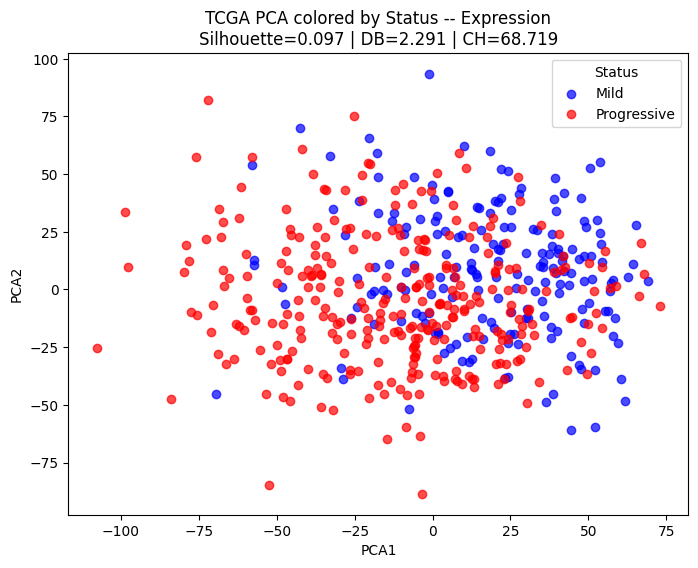

In [40]:
## ---- Count Matrix ----
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import umap
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# --- Load data ---
counts_tcga = pd.read_csv("../../../data/TCGA/count_matrix_filt.csv", index_col=0)
meta_tcga = pd.read_csv("../../../data/TCGA/metadata.csv")

# --- Standardize sample identifiers ---
meta_tcga = meta_tcga.rename(columns={"Sample_ID": "Sample"})

# --- Subset to aligned samples ---
counts_tcga = counts_tcga.loc[:, counts_tcga.columns.intersection(meta_tcga["Sample"])]
meta_tcga = meta_tcga[meta_tcga["Sample"].isin(counts_tcga.columns)]

# --- Add dataset label (optional) ---
meta_tcga["Dataset"] = "TCGA"

# --- Assign variables for workflow ---
metadata = meta_tcga.copy()
all_counts = counts_tcga.copy()

# ---- PCA & UMAP ----
X = all_counts.T.loc[metadata["Sample"]]

# --- PCA ---
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)
metadata["PCA1"] = pca_result[:, 0]
metadata["PCA2"] = pca_result[:, 1]

# --- UMAP ---
reducer = umap.UMAP(random_state=42)
umap_result = reducer.fit_transform(X)
metadata["UMAP1"] = umap_result[:, 0]
metadata["UMAP2"] = umap_result[:, 1]

# ---- Compute Cluster Quality Metrics ----
def compute_cluster_metrics(X_coords, labels):
    """Compute Silhouette, DB, and CH metrics safely."""
    if len(set(labels)) < 2:
        return np.nan, np.nan, np.nan
    sil = silhouette_score(X_coords, labels)
    db = davies_bouldin_score(X_coords, labels)
    ch = calinski_harabasz_score(X_coords, labels)
    return sil, db, ch

if "Status" in metadata.columns:
    X_pca = metadata[["PCA1", "PCA2"]]
    X_umap = metadata[["UMAP1", "UMAP2"]]
    labels = metadata["Status"]

    sil_pca, db_pca, ch_pca = compute_cluster_metrics(X_pca, labels)
    sil_umap, db_umap, ch_umap = compute_cluster_metrics(X_umap, labels)

    print(f"PCA  -> Silhouette: {sil_pca:.3f}, DB: {db_pca:.3f}, CH: {ch_pca:.3f}")
    print(f"UMAP -> Silhouette: {sil_umap:.3f}, DB: {db_umap:.3f}, CH: {ch_umap:.3f}")
else:
    print("⚠️ 'Status' column not found — cannot compute cluster metrics.")
    sil_pca = db_pca = ch_pca = sil_umap = db_umap = ch_umap = np.nan

# ---- Plotting ----
def plot_by_ighv(df, x, y, title):
    plt.figure(figsize=(8, 6))
    colors = {"Progressive": "red", "Mild": "blue"}
    for status in df["Status"].unique():
        subset = df[df["Status"] == status]
        plt.scatter(subset[x], subset[y],
                    c=colors.get(status, "gray"), label=status, alpha=0.7)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(title)
    plt.legend(title="Status")
    plt.show()

# ---- PCA Plot ----
pca_title = (f"TCGA PCA colored by Status -- Expression\n"
             f"Silhouette={sil_pca:.3f} | DB={db_pca:.3f} | CH={ch_pca:.3f}")
plot_by_ighv(metadata, "PCA1", "PCA2", pca_title)

# ---- UMAP Plot ----
#umap_title = (f"TCGA UMAP colored by Status\n"
#              f"Silhouette={sil_umap:.3f} | DB={db_umap:.3f} | CH={ch_umap:.3f}")
#plot_by_ighv(metadata, "UMAP1", "UMAP2", umap_title)


/home/vvasileiou/miniconda3/envs/lncAPNet/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


PCA  -> Silhouette: 0.046, DB: 3.344, CH: 31.335
UMAP -> Silhouette: 0.048, DB: 3.992, CH: 26.270


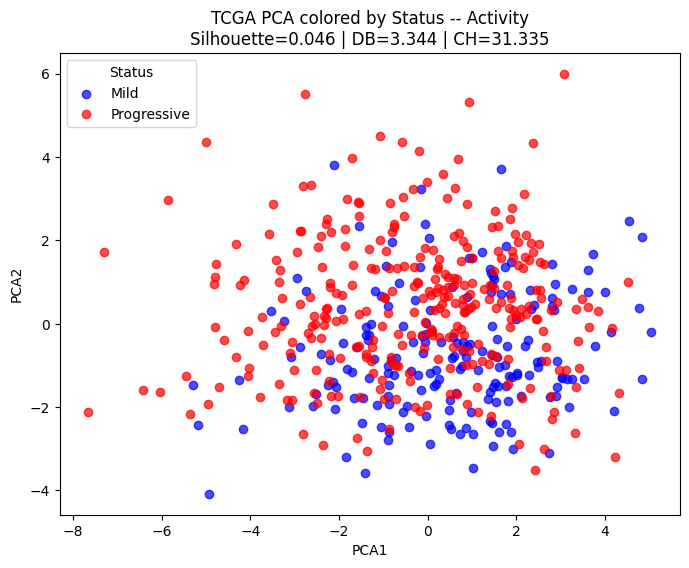

In [41]:
## ---- Count Matrix ----
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import umap
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# --- Load data ---
counts_tcga = pd.read_csv("../../../data/TCGA/activity_ens.csv", index_col=0)
meta_tcga = pd.read_csv("../../../data/TCGA/metadata.csv")

# --- Standardize sample identifiers ---
meta_tcga = meta_tcga.rename(columns={"Sample_ID": "Sample"})

# --- Subset to aligned samples ---
counts_tcga = counts_tcga.loc[:, counts_tcga.columns.intersection(meta_tcga["Sample"])]
meta_tcga = meta_tcga[meta_tcga["Sample"].isin(counts_tcga.columns)]

# --- Add dataset label (optional) ---
meta_tcga["Dataset"] = "TCGA"

# --- Assign variables for workflow ---
metadata = meta_tcga.copy()
all_counts = counts_tcga.copy()

# ---- PCA & UMAP ----
X = all_counts.T.loc[metadata["Sample"]]

# --- PCA ---
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)
metadata["PCA1"] = pca_result[:, 0]
metadata["PCA2"] = pca_result[:, 1]

# --- UMAP ---
reducer = umap.UMAP(random_state=42)
umap_result = reducer.fit_transform(X)
metadata["UMAP1"] = umap_result[:, 0]
metadata["UMAP2"] = umap_result[:, 1]

# ---- Compute Cluster Quality Metrics ----
def compute_cluster_metrics(X_coords, labels):
    """Compute Silhouette, DB, and CH metrics safely."""
    if len(set(labels)) < 2:
        return np.nan, np.nan, np.nan
    sil = silhouette_score(X_coords, labels)
    db = davies_bouldin_score(X_coords, labels)
    ch = calinski_harabasz_score(X_coords, labels)
    return sil, db, ch

if "Status" in metadata.columns:
    X_pca = metadata[["PCA1", "PCA2"]]
    X_umap = metadata[["UMAP1", "UMAP2"]]
    labels = metadata["Status"]

    sil_pca, db_pca, ch_pca = compute_cluster_metrics(X_pca, labels)
    sil_umap, db_umap, ch_umap = compute_cluster_metrics(X_umap, labels)

    print(f"PCA  -> Silhouette: {sil_pca:.3f}, DB: {db_pca:.3f}, CH: {ch_pca:.3f}")
    print(f"UMAP -> Silhouette: {sil_umap:.3f}, DB: {db_umap:.3f}, CH: {ch_umap:.3f}")
else:
    print("⚠️ 'Status' column not found — cannot compute cluster metrics.")
    sil_pca = db_pca = ch_pca = sil_umap = db_umap = ch_umap = np.nan

# ---- Plotting ----
def plot_by_ighv(df, x, y, title):
    plt.figure(figsize=(8, 6))
    colors = {"Progressive": "red", "Mild": "blue"}
    for status in df["Status"].unique():
        subset = df[df["Status"] == status]
        plt.scatter(subset[x], subset[y],
                    c=colors.get(status, "gray"), label=status, alpha=0.7)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(title)
    plt.legend(title="Status")
    plt.show()

# ---- PCA Plot ----
pca_title = (f"TCGA PCA colored by Status -- Activity\n"
             f"Silhouette={sil_pca:.3f} | DB={db_pca:.3f} | CH={ch_pca:.3f}")
plot_by_ighv(metadata, "PCA1", "PCA2", pca_title)

# ---- UMAP Plot ----
#umap_title = (f"TCGA UMAP colored by Status\n"
#              f"Silhouette={sil_umap:.3f} | DB={db_umap:.3f} | CH={ch_umap:.3f}")
#plot_by_ighv(metadata, "UMAP1", "UMAP2", umap_title)


In [23]:
res_tcga = pd.read_excel("../../results/TCGA/TCGA_NetBID2_ms_tab.xlsx")
res_tcga = res_tcga[['originalID', 'funcType', 'Size',
                     'logFC.U.Vs.M_DA', 'adj.P.Val.U.Vs.M_DA', 'Z.U.Vs.M_DA',
                     'logFC.U.Vs.M_DE', 'adj.P.Val.U.Vs.M_DE', 'Z.U.Vs.M_DE']]

res_tcga.rename(columns={
    'originalID': 'ID',
    'funcType': 'Type',
    'logFC.U.Vs.M_DA': 'logFC_DA',
    'adj.P.Val.U.Vs.M_DA': 'adj.P.Val_DA',
    'Z.U.Vs.M_DA': 'Z-score_DA',
    'logFC.U.Vs.M_DE': 'logFC_DE',
    'adj.P.Val.U.Vs.M_DE': 'adj.P.Val_DE',
    'Z.U.Vs.M_DE': 'Z-score_DE',
}, inplace=True)

# Create a temporary column to give priority to "TF" rows
res_tcga['priority'] = res_tcga['Type'].apply(lambda x: 0 if x == 'TF' else 1)

# Sort by priority and ID
res_tcga = res_tcga.sort_values(by=['priority', 'ID'])

# Drop duplicates, keeping TF first
res_tcga = res_tcga.drop_duplicates(subset='ID', keep='first')

# Drop helper column
res_tcga = res_tcga.drop(columns=['priority'])

# Apply filters
res_tcga_filt_overt = res_tcga[
    (res_tcga['adj.P.Val_DA'] < 0.05) &
    (res_tcga['adj.P.Val_DE'] < 0.05) &
    (res_tcga['Size'] > 30)
]

res_tcga_filt_hidden = res_tcga[
    (res_tcga['adj.P.Val_DA'] < 0.05) &
    (res_tcga['adj.P.Val_DE'] > 0.05) &
    (res_tcga['Size'] > 30)
]

# Print summary
print("Overt Drivers:", len(res_tcga_filt_overt))
print("Hidden Drivers:", len(res_tcga_filt_hidden))
print("Overt TFs:", len(res_tcga_filt_overt[res_tcga_filt_overt['Type'] == "TF"]))
print("Overt SIGs:", len(res_tcga_filt_overt[res_tcga_filt_overt['Type'] == "SIG"]))
print("Overt NCs:", len(res_tcga_filt_overt[res_tcga_filt_overt['Type'] == "NC"]))
print("Hidden TFs:", len(res_tcga_filt_hidden[res_tcga_filt_hidden['Type'] == "TF"]))
print("Hidden SIGs:", len(res_tcga_filt_hidden[res_tcga_filt_hidden['Type'] == "SIG"]))
print("Hidden NCs:", len(res_tcga_filt_hidden[res_tcga_filt_hidden['Type'] == "NC"]))


Overt Drivers: 2609
Hidden Drivers: 1722
Overt TFs: 380
Overt SIGs: 1283
Overt NCs: 946
Hidden TFs: 290
Hidden SIGs: 649
Hidden NCs: 783


In [24]:
shap_validation_go = pd.read_csv("../../PASNet/Output/GO/feature_importance_table.csv", index_col=0)
shap_validation_go_top20 = shap_validation_go.sort_values(by="Importance", ascending=False).head(50)

shap_validation_rest = pd.read_csv("../../PASNet/Output/REST/feature_importance_table.csv", index_col=0)
shap_validation_rest_top20 = shap_validation_rest.sort_values(by="Importance", ascending=False).head(50)

In [25]:
# Step 1: Get the feature names (index) from both DataFrames
features_rest = shap_validation_rest_top20.index
features_go = shap_validation_go_top20.index

# Step 2: Combine the feature names
combined_features = features_rest.to_list() + features_go.to_list()

# Step 3: Remove duplicates
unique_features = pd.Index(combined_features).unique()

# Optional: Convert to DataFrame if needed
features_df = pd.DataFrame(unique_features, columns=['Feature'])

In [26]:
res_tcga_filt = res_tcga[res_tcga['ID'].isin(features_df['Feature'])]
len(res_tcga_filt)

84

/home/vvasileiou/miniconda3/envs/lncAPNet/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


PCA  -> Silhouette: 0.070, DB: 2.617, CH: 49.385
UMAP -> Silhouette: 0.086, DB: 2.796, CH: 48.136


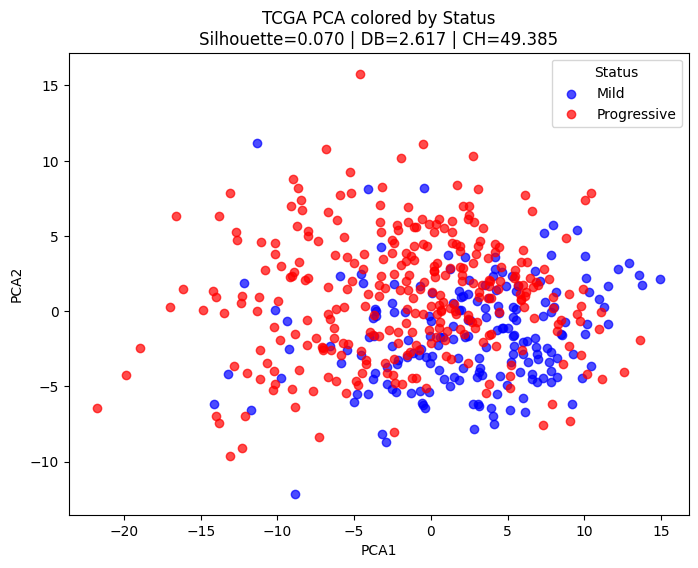

In [34]:
# --- Load data ---
counts_tcga = pd.read_csv("../../../data/TCGA/count_matrix_filt.csv", index_col=0)
meta_tcga = pd.read_csv("../../../data/TCGA/metadata.csv")

# Standardize sample identifiers
meta_tcga = meta_tcga.rename(columns={"Sample_ID": "Sample"})

# Subset to aligned samples
counts_tcga = counts_tcga.loc[:, counts_tcga.columns.intersection(meta_tcga["Sample"])]
meta_tcga = meta_tcga[meta_tcga["Sample"].isin(counts_tcga.columns)]

# Add dataset label (optional)
meta_tcga["Dataset"] = "TCGA"

# --- Filter genes by res_tcga_filt['ID'] ---
filtered_gene_ids = res_tcga_filt["ID"].unique()
counts_tcga = counts_tcga.loc[counts_tcga.index.intersection(filtered_gene_ids)]

# --- Assign variables for workflow ---
metadata = meta_tcga.copy()
all_counts = counts_tcga.copy()

# --- PCA & UMAP ---
X = all_counts.T.loc[metadata["Sample"]]

# PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)
metadata["PCA1"] = pca_result[:, 0]
metadata["PCA2"] = pca_result[:, 1]

# UMAP
import umap
reducer = umap.UMAP(random_state=42)
umap_result = reducer.fit_transform(X)
metadata["UMAP1"] = umap_result[:, 0]
metadata["UMAP2"] = umap_result[:, 1]

# --- Cluster Quality Metrics ---
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

def compute_cluster_metrics(X_coords, labels):
    """Compute Silhouette, DB, and CH metrics safely."""
    if len(set(labels)) < 2:
        return (np.nan, np.nan, np.nan)
    sil = silhouette_score(X_coords, labels)
    db = davies_bouldin_score(X_coords, labels)
    ch = calinski_harabasz_score(X_coords, labels)
    return sil, db, ch

# Compute for PCA and UMAP
if "Status" in metadata.columns:
    X_pca = metadata[["PCA1", "PCA2"]]
    X_umap = metadata[["UMAP1", "UMAP2"]]
    labels = metadata["Status"]

    sil_pca, db_pca, ch_pca = compute_cluster_metrics(X_pca, labels)
    sil_umap, db_umap, ch_umap = compute_cluster_metrics(X_umap, labels)

    print(f"PCA  -> Silhouette: {sil_pca:.3f}, DB: {db_pca:.3f}, CH: {ch_pca:.3f}")
    print(f"UMAP -> Silhouette: {sil_umap:.3f}, DB: {db_umap:.3f}, CH: {ch_umap:.3f}")
else:
    print("⚠️ 'Status' column not found — cannot compute cluster metrics.")
    sil_pca = db_pca = ch_pca = sil_umap = db_umap = ch_umap = np.nan

# --- Plotting ---
import matplotlib.pyplot as plt

def plot_by_ighv(df, x, y, title):
    plt.figure(figsize=(8, 6))
    colors = {"Progressive": "red", "Mild": "blue"}
    for status in df["Status"].unique():
        subset = df[df["Status"] == status]
        plt.scatter(subset[x], subset[y],
                    c=colors.get(status, "gray"), label=status, alpha=0.7)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(title)
    plt.legend(title="Status")
    plt.show()

# --- PCA Plot ---
pca_title = (f"TCGA PCA colored by Status\n"
             f"Silhouette={sil_pca:.3f} | DB={db_pca:.3f} | CH={ch_pca:.3f}")
plot_by_ighv(metadata, "PCA1", "PCA2", pca_title)

# --- UMAP Plot ---
#umap_title = (f"TCGA UMAP colored by Status\n"
#              f"Silhouette={sil_umap:.3f} | DB={db_umap:.3f} | CH={ch_umap:.3f}")
#plot_by_ighv(metadata, "UMAP1", "UMAP2", umap_title)


/home/vvasileiou/miniconda3/envs/lncAPNet/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


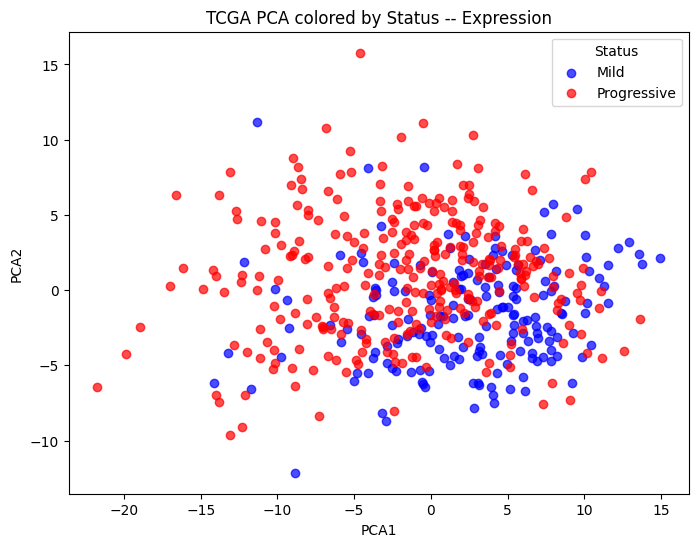

In [29]:
# --- Load data ---
counts_tcga = pd.read_csv("../../../data/TCGA/count_matrix_filt.csv", index_col=0)
meta_tcga = pd.read_csv("../../../data/TCGA/metadata.csv")

# Standardize sample identifiers
meta_tcga = meta_tcga.rename(columns={"Sample_ID": "Sample"})

# Subset to aligned samples
counts_tcga = counts_tcga.loc[:, counts_tcga.columns.intersection(meta_tcga["Sample"])]
meta_tcga = meta_tcga[meta_tcga["Sample"].isin(counts_tcga.columns)]

# Add dataset label (optional)
meta_tcga["Dataset"] = "TCGA"

# --- Filter genes by res_tcga_filt['ID'] ---
# Assuming res_tcga_filt is already loaded and contains a column 'ID' with gene identifiers
filtered_gene_ids = res_tcga_filt["ID"].unique()
counts_tcga = counts_tcga.loc[counts_tcga.index.intersection(filtered_gene_ids)]

# --- Assign variables for workflow ---
metadata = meta_tcga.copy()
all_counts = counts_tcga.copy()

# --- PCA & UMAP ---
X = all_counts.T.loc[metadata["Sample"]]

# PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)
metadata["PCA1"] = pca_result[:, 0]
metadata["PCA2"] = pca_result[:, 1]

# UMAP
import umap
reducer = umap.UMAP(random_state=42)
umap_result = reducer.fit_transform(X)
metadata["UMAP1"] = umap_result[:, 0]
metadata["UMAP2"] = umap_result[:, 1]

# --- Plotting ---
import matplotlib.pyplot as plt

def plot_by_ighv(df, x, y, title):
    plt.figure(figsize=(8, 6))
    colors = {"Progressive": "red", "Mild": "blue"}
    for status in df["Status"].unique():
        subset = df[df["Status"] == status]
        plt.scatter(subset[x], subset[y], 
                    c=colors.get(status, "gray"), label=status, alpha=0.7)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(title)
    plt.legend(title="Status")
    plt.show()

# PCA colored by Status
plot_by_ighv(metadata, "PCA1", "PCA2", "TCGA PCA colored by Status -- Expression")

# Optionally: UMAP colored by Status
# plot_by_ighv(metadata, "UMAP1", "UMAP2", "TCGA UMAP colored by Status -- Filtered Genes")


/home/vvasileiou/miniconda3/envs/lncAPNet/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


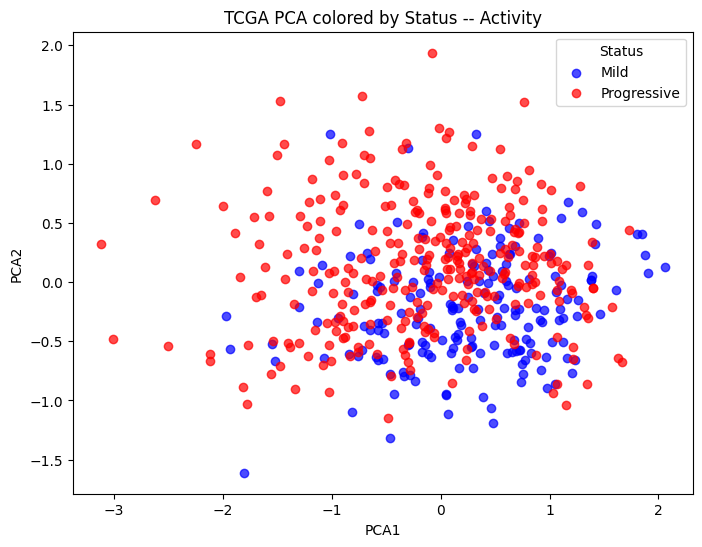

In [30]:
# --- Load data ---
counts_tcga = pd.read_csv("../../../data/TCGA/activity_ens.csv", index_col=0)
meta_tcga = pd.read_csv("../../../data/TCGA/metadata.csv")

# Standardize sample identifiers
meta_tcga = meta_tcga.rename(columns={"Sample_ID": "Sample"})

# Subset to aligned samples
counts_tcga = counts_tcga.loc[:, counts_tcga.columns.intersection(meta_tcga["Sample"])]
meta_tcga = meta_tcga[meta_tcga["Sample"].isin(counts_tcga.columns)]

# Add dataset label (optional)
meta_tcga["Dataset"] = "TCGA"

# --- Filter features by res_tcga_filt['ID'] ---
# Assumes res_tcga_filt is a DataFrame containing a column 'ID' with the feature identifiers
filtered_gene_ids = res_tcga_filt["ID"].unique()
counts_tcga = counts_tcga.loc[counts_tcga.index.intersection(filtered_gene_ids)]

# --- Assign variables for workflow ---
metadata = meta_tcga.copy()
all_counts = counts_tcga.copy()

# --- PCA & UMAP ---
from sklearn.decomposition import PCA
import umap

X = all_counts.T.loc[metadata["Sample"]]

# PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)
metadata["PCA1"] = pca_result[:, 0]
metadata["PCA2"] = pca_result[:, 1]

# UMAP
reducer = umap.UMAP(random_state=42)
umap_result = reducer.fit_transform(X)
metadata["UMAP1"] = umap_result[:, 0]
metadata["UMAP2"] = umap_result[:, 1]

# --- Plotting ---
import matplotlib.pyplot as plt

def plot_by_ighv(df, x, y, title):
    plt.figure(figsize=(8, 6))
    colors = {"Progressive": "red", "Mild": "blue"}
    for status in df["Status"].unique():
        subset = df[df["Status"] == status]
        plt.scatter(subset[x], subset[y],
                    c=colors.get(status, "gray"), label=status, alpha=0.7)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(title)
    plt.legend(title="Status")
    plt.show()

# PCA colored by Status
plot_by_ighv(metadata, "PCA1", "PCA2", "TCGA PCA colored by Status -- Activity")

# Optionally: UMAP colored by Status
# plot_by_ighv(metadata, "UMAP1", "UMAP2", "TCGA UMAP colored by Status -- Activity (Filtered)")


/home/vvasileiou/miniconda3/envs/lncAPNet/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Silhouette score (PCA, Status): 0.047
Silhouette score (UMAP, Status): 0.057


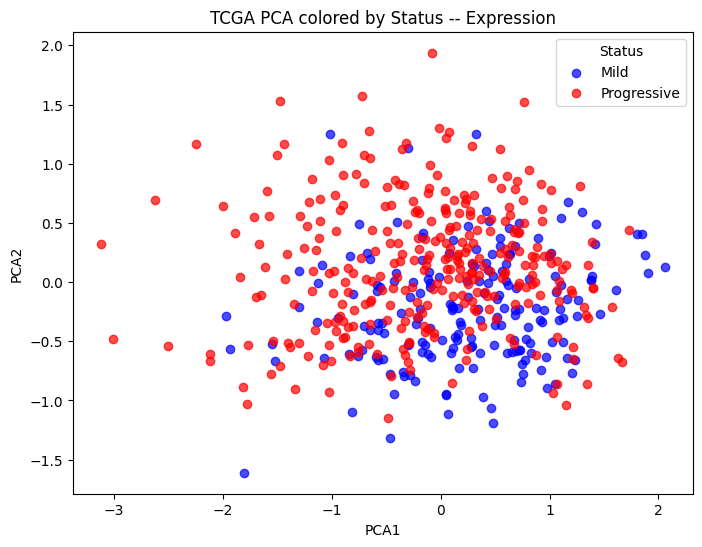

In [32]:
# --- Load data ---
counts_tcga = pd.read_csv("../../../data/TCGA/activity_ens.csv", index_col=0)
meta_tcga = pd.read_csv("../../../data/TCGA/metadata.csv")

# Standardize sample identifiers
meta_tcga = meta_tcga.rename(columns={"Sample_ID": "Sample"})

# Subset to aligned samples
counts_tcga = counts_tcga.loc[:, counts_tcga.columns.intersection(meta_tcga["Sample"])]
meta_tcga = meta_tcga[meta_tcga["Sample"].isin(counts_tcga.columns)]

# Add dataset label (optional)
meta_tcga["Dataset"] = "TCGA"

# --- Filter genes by res_tcga_filt['ID'] ---
filtered_gene_ids = res_tcga_filt["ID"].unique()
counts_tcga = counts_tcga.loc[counts_tcga.index.intersection(filtered_gene_ids)]

# --- Assign variables for workflow ---
metadata = meta_tcga.copy()
all_counts = counts_tcga.copy()

# --- PCA & UMAP ---
X = all_counts.T.loc[metadata["Sample"]]

# PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)
metadata["PCA1"] = pca_result[:, 0]
metadata["PCA2"] = pca_result[:, 1]

# UMAP
import umap
reducer = umap.UMAP(random_state=42)
umap_result = reducer.fit_transform(X)
metadata["UMAP1"] = umap_result[:, 0]
metadata["UMAP2"] = umap_result[:, 1]

# --- Silhouette Score Calculation ---
from sklearn.metrics import silhouette_score

# Check if 'Status' column exists before computing
if "Status" in metadata.columns:
    # PCA space
    X_pca = metadata[["PCA1", "PCA2"]]
    score_pca = silhouette_score(X_pca, metadata["Status"])
    print(f"Silhouette score (PCA, Status): {score_pca:.3f}")

    # UMAP space
    X_umap = metadata[["UMAP1", "UMAP2"]]
    score_umap = silhouette_score(X_umap, metadata["Status"])
    print(f"Silhouette score (UMAP, Status): {score_umap:.3f}")
else:
    print("⚠️ Column 'Status' not found in metadata — cannot compute silhouette score.")

# --- Plotting ---
import matplotlib.pyplot as plt

def plot_by_ighv(df, x, y, title):
    plt.figure(figsize=(8, 6))
    colors = {"Progressive": "red", "Mild": "blue"}
    for status in df["Status"].unique():
        subset = df[df["Status"] == status]
        plt.scatter(subset[x], subset[y], 
                    c=colors.get(status, "gray"), label=status, alpha=0.7)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(title)
    plt.legend(title="Status")
    plt.show()

# PCA colored by Status
plot_by_ighv(metadata, "PCA1", "PCA2", "TCGA PCA colored by Status -- Expression")

# Optionally: UMAP colored by Status
# plot_by_ighv(metadata, "UMAP1", "UMAP2", "TCGA UMAP colored by Status -- Filtered Genes")


/home/vvasileiou/miniconda3/envs/lncAPNet/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


PCA  -> Silhouette: 0.070, DB: 2.617, CH: 49.385
UMAP -> Silhouette: 0.086, DB: 2.796, CH: 48.136


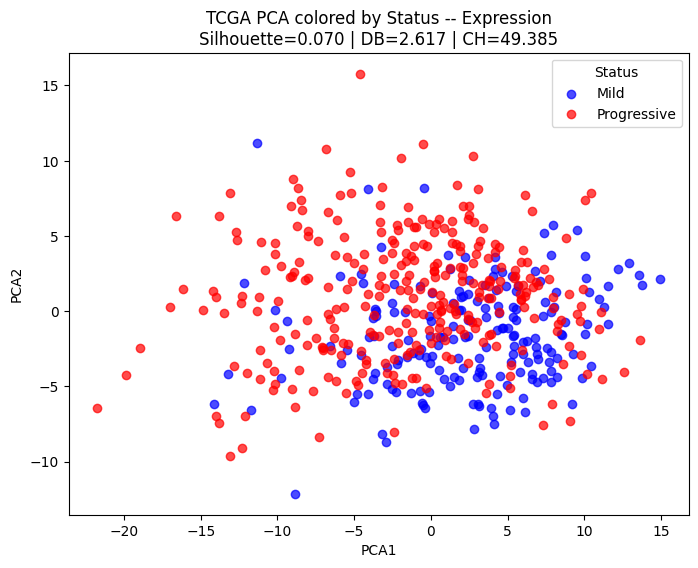

In [36]:
# --- Load data ---
counts_tcga = pd.read_csv("../../../data/TCGA/count_matrix_filt.csv", index_col=0)
meta_tcga = pd.read_csv("../../../data/TCGA/metadata.csv")

# Standardize sample identifiers
meta_tcga = meta_tcga.rename(columns={"Sample_ID": "Sample"})

# Subset to aligned samples
counts_tcga = counts_tcga.loc[:, counts_tcga.columns.intersection(meta_tcga["Sample"])]
meta_tcga = meta_tcga[meta_tcga["Sample"].isin(counts_tcga.columns)]

# Add dataset label (optional)
meta_tcga["Dataset"] = "TCGA"

# --- Filter genes by res_tcga_filt['ID'] ---
filtered_gene_ids = res_tcga_filt["ID"].unique()
counts_tcga = counts_tcga.loc[counts_tcga.index.intersection(filtered_gene_ids)]

# --- Assign variables for workflow ---
metadata = meta_tcga.copy()
all_counts = counts_tcga.copy()

# --- PCA & UMAP ---
X = all_counts.T.loc[metadata["Sample"]]

# PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)
metadata["PCA1"] = pca_result[:, 0]
metadata["PCA2"] = pca_result[:, 1]

# UMAP
import umap
reducer = umap.UMAP(random_state=42)
umap_result = reducer.fit_transform(X)
metadata["UMAP1"] = umap_result[:, 0]
metadata["UMAP2"] = umap_result[:, 1]

# --- Cluster Quality Metrics ---
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

def compute_cluster_metrics(X_coords, labels):
    """Compute Silhouette, DB, and CH metrics safely."""
    if len(set(labels)) < 2:
        return (np.nan, np.nan, np.nan)
    sil = silhouette_score(X_coords, labels)
    db = davies_bouldin_score(X_coords, labels)
    ch = calinski_harabasz_score(X_coords, labels)
    return sil, db, ch

# Compute for PCA and UMAP
if "Status" in metadata.columns:
    X_pca = metadata[["PCA1", "PCA2"]]
    X_umap = metadata[["UMAP1", "UMAP2"]]
    labels = metadata["Status"]

    sil_pca, db_pca, ch_pca = compute_cluster_metrics(X_pca, labels)
    sil_umap, db_umap, ch_umap = compute_cluster_metrics(X_umap, labels)

    print(f"PCA  -> Silhouette: {sil_pca:.3f}, DB: {db_pca:.3f}, CH: {ch_pca:.3f}")
    print(f"UMAP -> Silhouette: {sil_umap:.3f}, DB: {db_umap:.3f}, CH: {ch_umap:.3f}")
else:
    print("⚠️ 'Status' column not found — cannot compute cluster metrics.")
    sil_pca = db_pca = ch_pca = sil_umap = db_umap = ch_umap = np.nan

# --- Plotting ---
import matplotlib.pyplot as plt

def plot_by_ighv(df, x, y, title):
    plt.figure(figsize=(8, 6))
    colors = {"Progressive": "red", "Mild": "blue"}
    for status in df["Status"].unique():
        subset = df[df["Status"] == status]
        plt.scatter(subset[x], subset[y],
                    c=colors.get(status, "gray"), label=status, alpha=0.7)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(title)
    plt.legend(title="Status")
    plt.show()

# --- PCA Plot ---
pca_title = (f"TCGA PCA colored by Status -- Expression\n"
             f"Silhouette={sil_pca:.3f} | DB={db_pca:.3f} | CH={ch_pca:.3f}")
plot_by_ighv(metadata, "PCA1", "PCA2", pca_title)

# --- UMAP Plot ---
#umap_title = (f"TCGA UMAP colored by Status\n"
#              f"Silhouette={sil_umap:.3f} | DB={db_umap:.3f} | CH={ch_umap:.3f}")
#plot_by_ighv(metadata, "UMAP1", "UMAP2", umap_title)


/home/vvasileiou/miniconda3/envs/lncAPNet/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


PCA  -> Silhouette: 0.047, DB: 3.157, CH: 34.185
UMAP -> Silhouette: 0.057, DB: 3.388, CH: 34.563


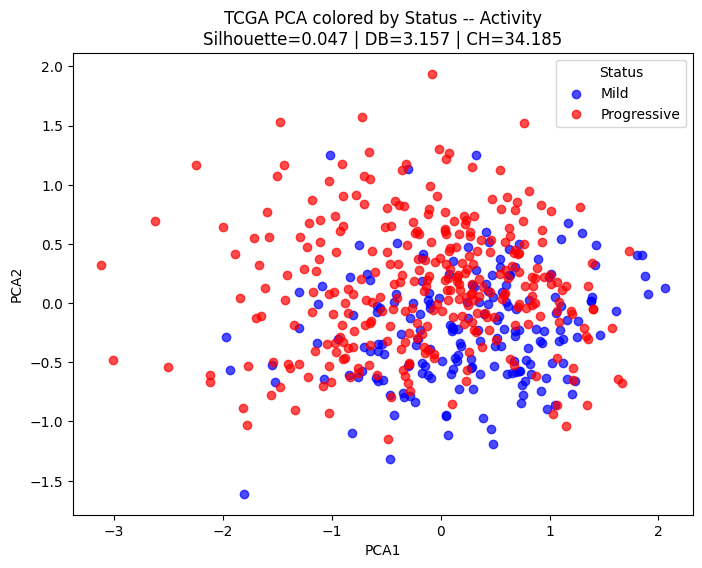

In [37]:
# --- Load data ---
counts_tcga = pd.read_csv("../../../data/TCGA/activity_ens.csv", index_col=0)
meta_tcga = pd.read_csv("../../../data/TCGA/metadata.csv")

# Standardize sample identifiers
meta_tcga = meta_tcga.rename(columns={"Sample_ID": "Sample"})

# Subset to aligned samples
counts_tcga = counts_tcga.loc[:, counts_tcga.columns.intersection(meta_tcga["Sample"])]
meta_tcga = meta_tcga[meta_tcga["Sample"].isin(counts_tcga.columns)]

# Add dataset label (optional)
meta_tcga["Dataset"] = "TCGA"

# --- Filter genes by res_tcga_filt['ID'] ---
filtered_gene_ids = res_tcga_filt["ID"].unique()
counts_tcga = counts_tcga.loc[counts_tcga.index.intersection(filtered_gene_ids)]

# --- Assign variables for workflow ---
metadata = meta_tcga.copy()
all_counts = counts_tcga.copy()

# --- PCA & UMAP ---
X = all_counts.T.loc[metadata["Sample"]]

# PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)
metadata["PCA1"] = pca_result[:, 0]
metadata["PCA2"] = pca_result[:, 1]

# UMAP
import umap
reducer = umap.UMAP(random_state=42)
umap_result = reducer.fit_transform(X)
metadata["UMAP1"] = umap_result[:, 0]
metadata["UMAP2"] = umap_result[:, 1]

# --- Cluster Quality Metrics ---
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

def compute_cluster_metrics(X_coords, labels):
    """Compute Silhouette, DB, and CH metrics safely."""
    if len(set(labels)) < 2:
        return (np.nan, np.nan, np.nan)
    sil = silhouette_score(X_coords, labels)
    db = davies_bouldin_score(X_coords, labels)
    ch = calinski_harabasz_score(X_coords, labels)
    return sil, db, ch

# Compute for PCA and UMAP
if "Status" in metadata.columns:
    X_pca = metadata[["PCA1", "PCA2"]]
    X_umap = metadata[["UMAP1", "UMAP2"]]
    labels = metadata["Status"]

    sil_pca, db_pca, ch_pca = compute_cluster_metrics(X_pca, labels)
    sil_umap, db_umap, ch_umap = compute_cluster_metrics(X_umap, labels)

    print(f"PCA  -> Silhouette: {sil_pca:.3f}, DB: {db_pca:.3f}, CH: {ch_pca:.3f}")
    print(f"UMAP -> Silhouette: {sil_umap:.3f}, DB: {db_umap:.3f}, CH: {ch_umap:.3f}")
else:
    print("⚠️ 'Status' column not found — cannot compute cluster metrics.")
    sil_pca = db_pca = ch_pca = sil_umap = db_umap = ch_umap = np.nan

# --- Plotting ---
import matplotlib.pyplot as plt

def plot_by_ighv(df, x, y, title):
    plt.figure(figsize=(8, 6))
    colors = {"Progressive": "red", "Mild": "blue"}
    for status in df["Status"].unique():
        subset = df[df["Status"] == status]
        plt.scatter(subset[x], subset[y],
                    c=colors.get(status, "gray"), label=status, alpha=0.7)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(title)
    plt.legend(title="Status")
    plt.show()

# --- PCA Plot ---
pca_title = (f"TCGA PCA colored by Status -- Activity\n"
             f"Silhouette={sil_pca:.3f} | DB={db_pca:.3f} | CH={ch_pca:.3f}")
plot_by_ighv(metadata, "PCA1", "PCA2", pca_title)

# --- UMAP Plot ---
#umap_title = (f"TCGA UMAP colored by Status\n"
#              f"Silhouette={sil_umap:.3f} | DB={db_umap:.3f} | CH={ch_umap:.3f}")
#plot_by_ighv(metadata, "UMAP1", "UMAP2", umap_title)
